#### A. IMPORT ESSENTIAL LIBRARIES & LOAD DATASET

In [2]:
# Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Paths
scripts_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/notebooks/eda_src"
data_exploration_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/exploration"

In [4]:
# Import Eda Libraries
os.chdir(scripts_path)
from exploration import coeff_var_skew, num_uni_hist_box
from ml_eda import confusion_matrix_display, classification_report_display, roc_curve_display, decision_tree_display

In [5]:
# Import Advanced Libraries
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix, classification_report, roc_curve, auc

In [6]:
# Load & Copy Dataset
os.chdir(data_exploration_path)
original_df = pd.read_csv("eda_processed_data.csv")
df = original_df.copy()

In [7]:
# First Column Drop
df.drop(columns='Unnamed: 0',inplace=True)

In [8]:
# Dataset Sample
df.sample(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Day,Month,IsWeekend,Regions,Topic Group
816,36.91,48,54645.20,159.69,0,1,2,2,0,Africa,4
690,87.16,33,60805.93,197.15,0,0,3,2,0,Asia,3
796,79.22,27,63429.18,198.79,1,0,4,3,0,Europe,4


#### B. FEATURE ENGINEERING

In [10]:
# Missing Value Check
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
Day                         0
Month                       0
IsWeekend                   0
Regions                     0
Topic Group                 0
dtype: int64

In [11]:
# Columns for Encoding
encoded_ncol = ['Day','Month','Regions','Topic Group']

In [12]:
# Encoded Dataset
df_encoded = pd.get_dummies(df, columns=encoded_ncol)

In [13]:
# Convert Booleans
df_processed = df_encoded.astype(int).copy()

#### C. GBOOSTING: ML ENGINEERING

In [15]:
# Define Columns: 
selected_col = ['Daily Internet Usage', 'Daily Time Spent on Site', 'Age', 'Area Income',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [16]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [17]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [18]:
# Load Model
gbc = GradientBoostingClassifier()

In [19]:
# Param Grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    'max_depth': [3, 4, 5],  # Maximum depth of each tree
}

In [20]:
# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(gbc, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [21]:
# Best Model
best_model = grid_search.best_estimator_

In [22]:
# Print Best Parameters and best score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation Accuracy: 0.9640 ± 0.0155


In [23]:
# Best Model
best_model = grid_search.best_estimator_

In [24]:
# Prediction
y_pred = best_model.predict(X_test)

In [25]:
# Predict Probabililty
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

In [26]:
# Classification Report
classification_report_display(y_test,y_pred)

Classification Report:
----------------------------------------
              precision    recall  f1-score  support
0              0.919355  0.950000  0.934426  120.000
1              0.952381  0.923077  0.937500  130.000
accuracy       0.936000  0.936000  0.936000    0.936
macro avg      0.935868  0.936538  0.935963  250.000
weighted avg   0.936528  0.936000  0.936025  250.000


In [27]:
# Confussion Matrix
confusion_matrix_display(y_test, y_pred, labels=['Class 0', 'Class 1'])

Confusion Matrix:
----------------------------------------
                Predicted Class 0  Predicted Class 1
Actual Class 0                114                  6
Actual Class 1                 10                120


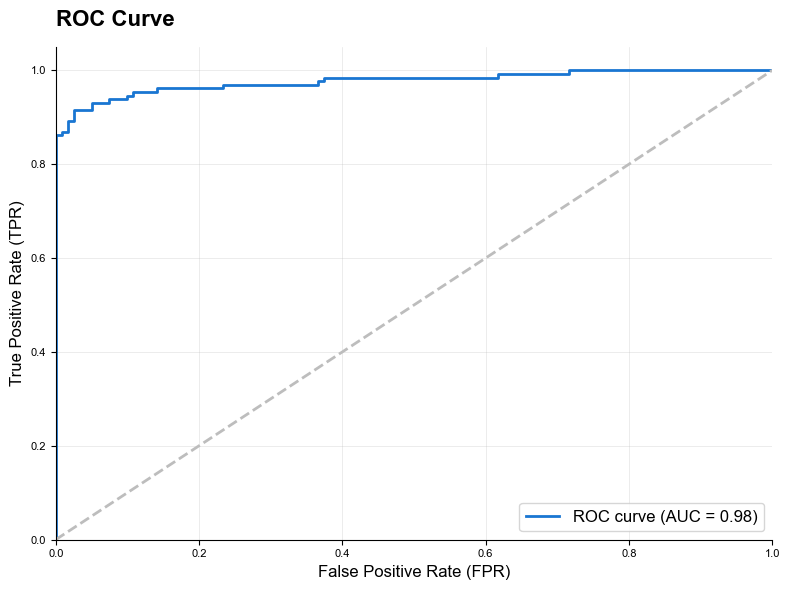

In [28]:
# ROC & AUC Curve
roc_curve_display(y_test, y_pred_prob, plot_title="ROC Curve")

In [29]:
# Feature Importance
pd.DataFrame(index=X.columns, data=best_model.feature_importances_, columns=['Feature Importance']).sort_values('Feature Importance',ascending=False)

,Feature Importance
Daily Internet Usage,0.749039
Daily Time Spent on Site,0.155272
Area Income,0.059419
Age,0.036271


In [30]:
# Shape Explainer
explainer = shap.TreeExplainer(best_model)

In [31]:
# Shap Values
shap_values = explainer.shap_values(X_test)

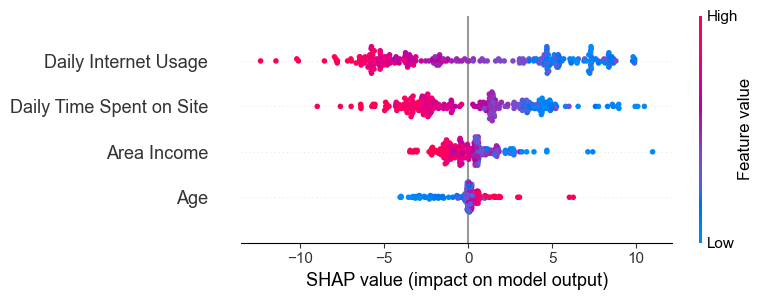

In [32]:
# Visualize SHAP Summary Plot 
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

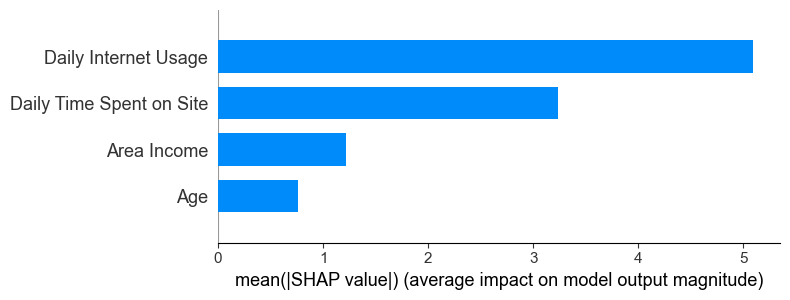

In [33]:
# Visualize SHAP Summary Plot in Bar Format
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), plot_type="bar")

#### D. GBOOSTING: FINAL MODEL

In [35]:
# Define Columns
selected_col = ['Daily Internet Usage', 'Daily Time Spent on Site', 'Age', 'Area Income',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [36]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [37]:
# Final Model Load
final_model = GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200)

In [38]:
# Final Model Fit
final_model.fit(X, y)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200)

In [39]:
# New Values
Daily_Internet_Usage = 208
Daily_Time_Spent_on_Site = 78
Age = 29
Area_Income = 66225


data = {
    'Daily Internet Usage': [Daily_Internet_Usage],
    'Daily Time Spent on Site': [Daily_Time_Spent_on_Site],
    'Age': [Age],
    'Area Income': [Area_Income],
}

new_pred = pd.DataFrame(data)
new_pred

,Daily Internet Usage,Daily Time Spent on Site,Age,Area Income
0,208,78,29,66225


In [40]:
# Predict Probabililty of Clicking
prob_class_0 = round(float(final_model.predict_proba(new_pred)[0][0]*100),2)
prob_class_1 = round(float(final_model.predict_proba(new_pred)[0][1]*100),2)
print(f"\033[1m- Probability of Class 0:\033[0m {prob_class_0}%")
print(f"\033[1m- Probability of Class 1:\033[0m {prob_class_1}%")

- Probability of Class 0: 99.84%
- Probability of Class 1: 0.16%
